In [1]:
# Imports and repo setup for F switch_on with a continuous Rzz orientation constraint.
from pathlib import Path
from collections import Counter
from dataclasses import asdict, dataclass
from io import BytesIO
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import torch
import pybullet as p
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "calvin_experiments" / "calvin_rollout_utils.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find guided-diffusion repo root")
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

from calvin_experiments import calvin_rollout_utils as CRU
from calvin_experiments import complex_stl_experiment_utils as complex_utils
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names
from calvin_experiments.train_dynamics_world_model import load_dynamics_model_for_eval

print("repo:", REPO_ROOT)
print("cuda:", torch.cuda.is_available())


pybullet build time: Jan 29 2025 23:16:28
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


repo: /home/moritz/src/guided-diffusion
cuda: True


In [2]:
# Load the diffusion policy, automaton model, and local dynamics model for Rzz guidance.
DEVICE = TorchUtils.get_torch_device(try_to_use_cuda=True)

POLICY_CKPT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38"
DYNAMICS_CKPT_PATH = REPO_ROOT / "outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08"
SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/robust_direction_initial.json"
VISUALIZATION_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/visualization_freiburg_style.json"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/paper_stls/F_switch_G_Rzz"

policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(POLICY_CKPT_PATH), device=DEVICE, verbose=False)
policy_epoch = CRU.policy_epoch_from_checkpoint(POLICY_CKPT_PATH)
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)
video_cfg = CRU.load_json_config(VISUALIZATION_CONFIG_PATH)

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, DEVICE)
label_names = list(automaton_meta["label_names"])
label_thresholds = automaton_meta.get("label_thresholds")
dynamics_model, dynamics_stats, dynamics_ckpt, dynamics_meta = load_dynamics_model_for_eval(DYNAMICS_CKPT_PATH, device=DEVICE)
dynamics_model.eval()
dynamics_stats_t = {k: torch.as_tensor(v, device=DEVICE, dtype=torch.float32).unsqueeze(0) for k, v in dynamics_stats.items()}

print("device:", DEVICE)
print("labels:", label_names)
print("policy:", POLICY_CKPT_PATH)
print("automaton:", AUTOMATON_CKPT_PATH)
print("dynamics:", DYNAMICS_CKPT_PATH)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['third_person', 'eye_in_hand']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
device: cuda:0
labels: ['switch_on', 'switch_off', 'button_on', 'button_off', 'button_pressed', 'drawer_open', 'drawer_closed', 'door_left', 'door_right']
policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38
dynamics: /home/moritz/src/guided-diffusion/outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08


In [3]:
# Rollout helpers and automaton sample-and-rank utilities.
env = None
base_env_state = None

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(scene[None, :], label_names, label_thresholds)[0].astype(np.float32)
    return automaton_state, automaton_label

def opposite_label_idx(target_label_idx):
    opposites = {
        "switch_on": "switch_off", "switch_off": "switch_on",
        "button_on": "button_off", "button_off": "button_on",
        "drawer_open": "drawer_closed", "drawer_closed": "drawer_open",
        "door_left": "door_right", "door_right": "door_left",
    }
    name = opposites.get(label_names[int(target_label_idx)])
    return None if name is None or name not in label_names else label_names.index(name)

def goal_label_indices(goal_names):
    missing = [name for name in goal_names if name not in label_names]
    if missing:
        raise KeyError(f"Unknown goal label(s): {missing}. Available labels: {label_names}")
    return [label_names.index(name) for name in goal_names]

def score_label_probs(label_probs, target_label_idx):
    scores = np.asarray(label_probs, dtype=np.float32)[..., int(target_label_idx)].copy()
    opp = opposite_label_idx(target_label_idx)
    if opp is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opp]
    return scores

def score_goal_probs(label_probs, goal_label_idxs):
    goal_label_idxs = [int(idx) for idx in goal_label_idxs]
    per_goal_scores = np.stack([score_label_probs(label_probs, idx) for idx in goal_label_idxs], axis=-1)
    best_goal_pos = np.argmax(per_goal_scores, axis=-1)
    flat_scores = per_goal_scores.reshape(-1, per_goal_scores.shape[-1])
    best_scores = flat_scores[np.arange(flat_scores.shape[0]), best_goal_pos.reshape(-1)].reshape(best_goal_pos.shape)
    return best_scores.astype(np.float32), best_goal_pos.astype(np.int64), per_goal_scores.astype(np.float32)

def repeat_obs_batch(obs_tensor, n):
    if int(n) == 1:
        return obs_tensor
    return {k: v.repeat((int(n),) + (1,) * (v.ndim - 1)) for k, v in obs_tensor.items()}

def unnormalize_action_sequence(action_sequence):
    action_np = CRU.to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {k: policy.action_normalization_stats[k]["offset"].shape[1:] for k in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    n_candidates, _, action_dim = action_chunks.shape
    action_chunk_dim = len(automaton_stats["actions_mean"])
    automaton_horizon = action_chunk_dim // action_dim
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=DEVICE, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=DEVICE, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

def rzz_from_euler_xyz_np(euler_xyz):
    euler_xyz = np.asarray(euler_xyz, dtype=np.float32)
    # Same convention as train_dynamics_world_model: R = Rz(yaw) @ Ry(pitch) @ Rx(roll).
    return np.cos(euler_xyz[..., 1]) * np.cos(euler_xyz[..., 0])

def rzz_to_tilt_angle_deg_np(rzz, rzz_spec):
    signed_cos = float(rzz_spec.axis_sign) * np.asarray(rzz, dtype=np.float32)
    return np.rad2deg(np.arccos(np.clip(signed_cos, -1.0, 1.0)))

def rzz_angle_error_deg_np(rzz, rzz_spec):
    return np.abs(rzz_to_tilt_angle_deg_np(rzz, rzz_spec) - float(rzz_spec.angle_deg))

def rzz_tolerance_band_deg_np(rzz_spec):
    angles = rzz_to_tilt_angle_deg_np(
        np.asarray([rzz_spec.target - rzz_spec.tolerance, rzz_spec.target + rzz_spec.tolerance], dtype=np.float32),
        rzz_spec,
    )
    return float(np.min(angles)), float(np.max(angles))

def euler_xyz_to_matrix_np(euler_xyz):
    roll, pitch, yaw = [float(v) for v in np.asarray(euler_xyz, dtype=np.float32)]
    sx, cx = np.sin(roll), np.cos(roll)
    sy, cy = np.sin(pitch), np.cos(pitch)
    sz, cz = np.sin(yaw), np.cos(yaw)
    return np.asarray([
        [cz * cy, cz * sy * sx - sz * cx, cz * sy * cx + sz * sx],
        [sz * cy, sz * sy * sx + cz * cx, sz * sy * cx - cz * sx],
        [-sy, cy * sx, cy * cx],
    ], dtype=np.float32)

def matrix_to_euler_xyz_np(rot):
    rot = np.asarray(rot, dtype=np.float64)
    pitch = np.arcsin(np.clip(-rot[2, 0], -1.0, 1.0))
    cp = np.cos(pitch)
    if abs(cp) < 1e-6:
        roll = 0.0
        yaw = np.arctan2(-rot[0, 1], rot[1, 1])
    else:
        roll = np.arctan2(rot[2, 1], rot[2, 2])
        yaw = np.arctan2(rot[1, 0], rot[0, 0])
    return np.asarray([roll, pitch, yaw], dtype=np.float32)

def target_tcp_z_axis_np(current_euler_xyz, rzz_spec):
    target_z = float(rzz_spec.target)
    horizontal = float(np.sqrt(max(0.0, 1.0 - target_z ** 2)))
    if horizontal < 1e-8:
        return np.asarray([0.0, 0.0, np.sign(target_z) if target_z != 0 else 1.0], dtype=np.float32)
    current_rot = euler_xyz_to_matrix_np(current_euler_xyz)
    direction = np.asarray(current_rot[:2, 2], dtype=np.float32)
    norm = float(np.linalg.norm(direction))
    if norm < 1e-8:
        direction = np.asarray(current_rot[:2, 0], dtype=np.float32)
        norm = float(np.linalg.norm(direction))
    if norm < 1e-8:
        direction = np.asarray([1.0, 0.0], dtype=np.float32)
    else:
        direction = direction / norm
    return np.asarray([horizontal * direction[0], horizontal * direction[1], target_z], dtype=np.float32)

def euler_with_target_tcp_z_axis(current_euler_xyz, target_z_axis):
    r3 = np.asarray(target_z_axis, dtype=np.float32)
    r3 = r3 / (np.linalg.norm(r3) + 1e-8)
    current_rot = euler_xyz_to_matrix_np(current_euler_xyz)
    r1 = current_rot[:, 0]
    r1 = r1 - np.dot(r1, r3) * r3
    if np.linalg.norm(r1) < 1e-6:
        fallback = np.asarray([1.0, 0.0, 0.0], dtype=np.float32)
        if abs(np.dot(fallback, r3)) > 0.95:
            fallback = np.asarray([0.0, 1.0, 0.0], dtype=np.float32)
        r1 = fallback - np.dot(fallback, r3) * r3
    r1 = r1 / (np.linalg.norm(r1) + 1e-8)
    r2 = np.cross(r3, r1)
    r2 = r2 / (np.linalg.norm(r2) + 1e-8)
    rot = np.stack([r1, r2, r3], axis=1)
    return matrix_to_euler_xyz_np(rot)

def angle_diff(a, b):
    return float(np.arctan2(np.sin(a - b), np.cos(a - b)))

def robot_with_target_rzz(robot, rzz_spec, env=None):
    robot = np.asarray(robot, dtype=np.float32).copy()
    original_rzz = float(rzz_from_euler_xyz_np(robot[3:6]))
    old_euler = np.asarray(robot[3:6], dtype=np.float32).copy()
    target_z_axis = target_tcp_z_axis_np(old_euler, rzz_spec)
    new_euler = euler_with_target_tcp_z_axis(old_euler, target_z_axis)
    robot[3:6] = new_euler

    reset_info = {
        "enabled": True,
        "old_euler_xyz": old_euler.tolist(),
        "new_euler_xyz": [float(v) for v in robot[3:6]],
        "old_rzz": original_rzz,
        "target_rzz": float(rzz_spec.target),
        "target_angle_deg": float(rzz_spec.angle_deg),
        "old_angle_deg": float(rzz_to_tilt_angle_deg_np(original_rzz, rzz_spec)),
        "requested_rzz": float(rzz_from_euler_xyz_np(robot[3:6])),
        "requested_angle_deg": float(rzz_to_tilt_angle_deg_np(rzz_from_euler_xyz_np(robot[3:6]), rzz_spec)),
        "target_tcp_z_axis": [float(v) for v in target_z_axis],
        "requested_tcp_z_axis": [float(v) for v in euler_xyz_to_matrix_np(robot[3:6])[:, 2]],
        "ik_applied": False,
    }
    if env is not None:
        calvin_env = CRU.get_calvin_unwrapped_env(env)
        target_quat = p.getQuaternionFromEuler(robot[3:6].tolist())
        ik_joints = np.asarray(calvin_env.robot.mixed_ik.get_ik(robot[:3], target_quat), dtype=np.float32)[:7]
        if ik_joints.shape[0] != 7 or not np.all(np.isfinite(ik_joints)):
            raise RuntimeError(f"IK failed for target TCP pose: joints={ik_joints}")
        robot[7:14] = ik_joints
        reset_info["ik_applied"] = True
        reset_info["ik_joints"] = ik_joints.tolist()
    return robot, reset_info


def restack_current_observation(env):
    if not hasattr(env, "_get_initial_obs_history"):
        return None
    robomimic_env = env.env
    raw_obs = getattr(robomimic_env, "_current_obs", None)
    obs = robomimic_env.get_observation(raw_obs)
    env.timestep = 0
    env.update_obs(obs, reset=True)
    env.obs_history = env._get_initial_obs_history(init_obs=obs)
    return env._get_stacked_obs_from_history()

def apply_rzz_action_warmup(env, obs, rzz_spec, max_steps=20, tolerance=None, save_video=False, restack_obs=True):
    tolerance = float(min(0.005, max(1e-4, 0.1 * float(rzz_spec.tolerance))) if tolerance is None else tolerance)
    start_robot = np.asarray(env.get_state()["robot"], dtype=np.float32).copy()
    target_axis = target_tcp_z_axis_np(start_robot[3:6], rzz_spec)
    target_euler = euler_with_target_tcp_z_axis(start_robot[3:6], target_axis)
    max_rel_orn = float(getattr(CRU.get_calvin_unwrapped_env(env).robot, "max_rel_orn", 0.05))
    warmup_actions, warmup_states, frames = [], [start_robot.copy()], []
    reached = abs(float(rzz_from_euler_xyz_np(start_robot[3:6])) - float(rzz_spec.target)) <= tolerance
    done = False
    for _ in range(int(max_steps)):
        if reached or done:
            break
        robot = np.asarray(env.get_state()["robot"], dtype=np.float32).copy()
        delta_euler = np.asarray([angle_diff(float(target_euler[i]), float(robot[3 + i])) for i in range(3)], dtype=np.float32)
        action = np.zeros(7, dtype=np.float32)
        action[3:6] = np.clip(delta_euler / max(max_rel_orn, 1e-6), -1.0, 1.0)
        action[6] = 1.0
        warmup_actions.append(action.copy())
        obs, _, done, _ = env.step(action.copy())
        new_robot = np.asarray(env.get_state()["robot"], dtype=np.float32).copy()
        warmup_states.append(new_robot.copy())
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))
        reached = abs(float(rzz_from_euler_xyz_np(new_robot[3:6])) - float(rzz_spec.target)) <= tolerance
    if restack_obs:
        restacked = restack_current_observation(env)
        if restacked is not None:
            obs = restacked
    final_robot = np.asarray(env.get_state()["robot"], dtype=np.float32).copy()
    info = {
        "enabled": True,
        "mode": "warmup",
        "target_rzz": float(rzz_spec.target),
        "tolerance": tolerance,
        "target_tcp_z_axis": [float(v) for v in target_axis],
        "target_euler_xyz": [float(v) for v in target_euler],
        "start_xyz": start_robot[:3].astype(float).tolist(),
        "start_rzz": float(rzz_from_euler_xyz_np(start_robot[3:6])),
        "start_angle_deg": float(rzz_to_tilt_angle_deg_np(rzz_from_euler_xyz_np(start_robot[3:6]), rzz_spec)),
        "final_xyz": final_robot[:3].astype(float).tolist(),
        "final_rzz": float(rzz_from_euler_xyz_np(final_robot[3:6])),
        "final_angle_deg": float(rzz_to_tilt_angle_deg_np(rzz_from_euler_xyz_np(final_robot[3:6]), rzz_spec)),
        "final_angle_error_deg": float(rzz_angle_error_deg_np(rzz_from_euler_xyz_np(final_robot[3:6]), rzz_spec)),
        "xyz_drift": (final_robot[:3] - start_robot[:3]).astype(float).tolist(),
        "n_steps": len(warmup_actions),
        "reached_tolerance": bool(reached),
        "restacked_obs": bool(restack_obs),
        "actions": np.asarray(warmup_actions, dtype=np.float32).tolist(),
        "rzz_trace": [float(rzz_from_euler_xyz_np(state[3:6])) for state in warmup_states],
        "angle_deg_trace": [float(rzz_to_tilt_angle_deg_np(rzz_from_euler_xyz_np(state[3:6]), rzz_spec)) for state in warmup_states],
        "xyz_trace": [state[:3].astype(float).tolist() for state in warmup_states],
    }
    return obs, info, frames

def rollout_policy_once(seed, action_sampler, output_dir, rollout_tag, horizon=150, save_video=True, stop_on_behavior=True, initialize_robot_rzz=False, rzz_spec=None, rzz_init_mode="none", rzz_warmup_max_steps=20, rzz_warmup_tolerance=None, restack_after_warmup=True):
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(seed), suppress_output=True)
    fixed_scene, fixed_robot, active_scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)
    if initialize_robot_rzz and rzz_init_mode == "none":
        rzz_init_mode = "ik"
    reset_rzz = {"enabled": False, "mode": "none", "old_rzz": float(rzz_from_euler_xyz_np(fixed_robot[3:6]))}
    if rzz_init_mode not in ("none", "ik", "warmup"):
        raise ValueError(f"Unknown rzz_init_mode={rzz_init_mode!r}; expected 'none', 'ik', or 'warmup'")
    if rzz_init_mode == "ik":
        if rzz_spec is None:
            raise ValueError("rzz_init_mode='ik' requires rzz_spec")
        fixed_robot, reset_rzz = robot_with_target_rzz(fixed_robot, rzz_spec, env=env)
        reset_rzz["mode"] = "ik"

    CRU.seed_everything(seed)
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    frames = [CRU.render_visual_camera(env, video_cfg)] if save_video else []
    if rzz_init_mode == "warmup":
        if rzz_spec is None:
            raise ValueError("rzz_init_mode='warmup' requires rzz_spec")
        obs, reset_rzz, warmup_frames = apply_rzz_action_warmup(
            env, obs, rzz_spec,
            max_steps=rzz_warmup_max_steps, tolerance=rzz_warmup_tolerance,
            save_video=save_video, restack_obs=restack_after_warmup,
        )
        frames.extend(warmup_frames)
    policy.start_episode()
    scene_snapshot = CRU.capture_scene_snapshot(env)

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    start_robot = np.asarray(start_state["robot"], dtype=np.float32).copy()
    reset_rzz["actual_start_rzz"] = float(rzz_from_euler_xyz_np(start_robot[3:6]))
    binaries = CRU.articulated_binaries_from_start_state(start_scene)
    _, label0 = current_automaton_state_and_label(env)

    actions, rewards, dones, records = [], [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [start_robot.copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    tcp_rzz = [float(rzz_from_euler_xyz_np(robot_states[-1][3:6]))]
    action_queue = []
    behavior, behavior_step, termination_reason = "none", -1, "horizon"

    for step in range(int(horizon)):
        if not action_queue:
            new_actions, record = action_sampler(obs, env, step)
            action_queue.extend(np.asarray(new_actions, dtype=np.float32))
            records.append(record)
        action = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
        actions.append(action.copy())

        obs, reward, done, _ = env.step(action)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()
        rewards.append(float(reward)); dones.append(bool(done))
        scene_states.append(scene); robot_states.append(robot); eef_xy.append(robot[:2].copy())
        tcp_rzz.append(float(rzz_from_euler_xyz_np(robot[3:6])))
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))

        if behavior_step < 0 and CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False):
            behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            behavior_step = step + 1
            if stop_on_behavior:
                termination_reason = "behavior"
                break
        if done:
            termination_reason = "env_done"
            break

    _, labelf = current_automaton_state_and_label(env)
    rollout = {
        "scene_config": active_scene_cfg["name"], "seed": int(seed), "behavior": behavior,
        "behavior_step": int(behavior_step), "termination_step": len(actions), "termination_reason": termination_reason,
        "return": float(np.sum(rewards)), "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32), "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32), "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32), "tcp_rzz": np.asarray(tcp_rzz, dtype=np.float32),
        "initial_label": label0.astype(int).tolist(), "final_label": labelf.astype(int).tolist(),
        "records": records, "scene_snapshot": scene_snapshot, "reset_rzz": reset_rzz,
    }
    if save_video:
        CRU.save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=30)
    return rollout


In [4]:
# Rzz robustness and local dynamics-guided post-sample action refinement.
@dataclass
class RzzSpec:
    angle_deg: float = 30.0
    axis_sign: float = -1.0  # CALVIN's TCP z-axis normally points downward, so -cos(angle) means a downward 30 degree tilt.
    tolerance: float = 0.05
    smooth_min_tau: float = 0.02

    @property
    def target(self):
        return float(self.axis_sign * np.cos(np.deg2rad(self.angle_deg)))

def euler_xyz_to_rot6d_torch(euler_xyz):
    x, y, z = euler_xyz[..., 0], euler_xyz[..., 1], euler_xyz[..., 2]
    sx, cx = torch.sin(x), torch.cos(x)
    sy, cy = torch.sin(y), torch.cos(y)
    sz, cz = torch.sin(z), torch.cos(z)
    return torch.stack([cz * cy, sz * cy, -sy, cz * sy * sx - sz * cx, sz * sy * sx + cz * cx, cy * sx], dim=-1)

def raw_env_state_to_dynamics_state_torch(robot, scene):
    robot_t = torch.as_tensor(robot, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    scene_t = torch.as_tensor(scene, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    robot_dyn = torch.cat([robot_t[..., :3], euler_xyz_to_rot6d_torch(robot_t[..., 3:6]), robot_t[..., 6:]], dim=-1)
    scene_parts = [scene_t[..., :6]]
    for start in (6, 12, 18):
        scene_parts += [scene_t[..., start:start + 3], euler_xyz_to_rot6d_torch(scene_t[..., start + 3:start + 6])]
    return torch.cat([robot_dyn, torch.cat(scene_parts, dim=-1)], dim=-1)

def project_rot6d_torch(rot6d):
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r1 = r1 / (torch.linalg.norm(r1, dim=-1, keepdim=True) + 1e-8)
    r2 = r2 - torch.sum(r1 * r2, dim=-1, keepdim=True) * r1
    r2 = r2 / (torch.linalg.norm(r2, dim=-1, keepdim=True) + 1e-8)
    return torch.cat([r1, r2], dim=-1)

def rot6d_to_rzz_torch(rot6d):
    rot6d = project_rot6d_torch(rot6d)
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r3 = torch.cross(r1, r2, dim=-1)
    return r3[..., 2]

def project_dynamics_state_torch(state):
    pieces, cursor = [], 0
    for start, end in [(3, 9), (27, 33), (36, 42), (45, 51)]:
        pieces += [state[..., cursor:start], project_rot6d_torch(state[..., start:end])]
        cursor = end
    return torch.cat(pieces + [state[..., cursor:]], dim=-1)

def dynamics_rollout_torch(state_dyn, action_chunk):
    if action_chunk.ndim == 2:
        action_chunk = action_chunk.unsqueeze(0)
    state = state_dyn.expand(action_chunk.shape[0], -1)
    states = []
    for t in range(action_chunk.shape[1]):
        state_n = (state - dynamics_stats_t["state_mean"]) / dynamics_stats_t["state_std"]
        action_n = (action_chunk[:, t, :] - dynamics_stats_t["action_mean"]) / dynamics_stats_t["action_std"]
        delta_n = dynamics_model(state_n, action_n)
        delta = delta_n * dynamics_stats_t["delta_std"] + dynamics_stats_t["delta_mean"]
        state = project_dynamics_state_torch(state + delta)
        states.append(state)
    return torch.stack(states, dim=1)

def rzz_robustness_torch(state_dyn, action_chunk, rzz_spec):
    pred_states = dynamics_rollout_torch(state_dyn, action_chunk)
    pred_rzz = rot6d_to_rzz_torch(pred_states[..., 3:9])
    target = torch.as_tensor(rzz_spec.target, device=pred_rzz.device, dtype=pred_rzz.dtype)
    abs_error = torch.abs(pred_rzz - target)
    margins = float(rzz_spec.tolerance) - abs_error
    tau = max(float(rzz_spec.smooth_min_tau), 1e-6)
    smooth_min_margin = -tau * torch.logsumexp(-margins / tau, dim=-1)
    mean_sq_error = torch.mean((pred_rzz - target) ** 2, dim=-1)
    return smooth_min_margin, pred_rzz, abs_error, mean_sq_error

def refine_action_chunk_for_rzz(robot, scene, action_chunk, rzz_spec, guidance_scale=100.0, gradient_steps=20, step_size=0.03, action_reg=0.01, action_dims=(3, 4, 5)):
    state_dyn = raw_env_state_to_dynamics_state_torch(robot, scene)
    original = torch.as_tensor(action_chunk[None], device=DEVICE, dtype=torch.float32)
    actions = original.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([actions], lr=float(step_size))
    action_dims = None if action_dims is None else tuple(int(d) for d in action_dims)
    history = []

    with torch.no_grad():
        robust_before, pred_rzz_before, abs_error_before, mse_before = rzz_robustness_torch(state_dyn, original, rzz_spec)

    for _ in range(int(gradient_steps)):
        opt.zero_grad(set_to_none=True)
        robust, _, _, mse = rzz_robustness_torch(state_dyn, actions, rzz_spec)
        action_penalty = torch.mean((actions - original) ** 2, dim=(1, 2))
        objective = -float(guidance_scale) * mse - float(action_reg) * action_penalty
        (-objective.mean()).backward()
        opt.step()
        with torch.no_grad():
            if action_dims is not None:
                keep = original.clone()
                keep[..., list(action_dims)] = actions[..., list(action_dims)]
                actions.copy_(keep)
            actions.clamp_(-1.0, 1.0)
            history.append({"robustness": float(robust[0].detach().cpu()), "mse": float(mse[0].detach().cpu()), "objective": float(objective[0].detach().cpu())})

    with torch.no_grad():
        robust_after, pred_rzz_after, abs_error_after, mse_after = rzz_robustness_torch(state_dyn, actions, rzz_spec)
        non_guided_l2 = 0.0
        if action_dims is not None:
            mask = torch.ones(actions.shape[-1], device=DEVICE, dtype=torch.bool)
            mask[list(action_dims)] = False
            non_guided_l2 = float(torch.linalg.norm((actions - original)[..., mask]).detach().cpu())

    pred_angle_before = rzz_to_tilt_angle_deg_np(pred_rzz_before[0].detach().cpu().numpy(), rzz_spec)
    pred_angle_after = rzz_to_tilt_angle_deg_np(pred_rzz_after[0].detach().cpu().numpy(), rzz_spec)
    angle_error_before = np.abs(pred_angle_before - float(rzz_spec.angle_deg))
    angle_error_after = np.abs(pred_angle_after - float(rzz_spec.angle_deg))

    record = {
        "target_rzz": rzz_spec.target,
        "target_angle_deg": float(rzz_spec.angle_deg),
        "tolerance": float(rzz_spec.tolerance),
        "robust_before": float(robust_before[0].cpu()),
        "robust_after": float(robust_after[0].cpu()),
        "mse_before": float(mse_before[0].cpu()),
        "mse_after": float(mse_after[0].cpu()),
        "mean_abs_rzz_error_before": float(abs_error_before[0].mean().cpu()),
        "mean_abs_rzz_error_after": float(abs_error_after[0].mean().cpu()),
        "mean_abs_angle_error_deg_before": float(np.mean(angle_error_before)),
        "mean_abs_angle_error_deg_after": float(np.mean(angle_error_after)),
        "pred_rzz_before": pred_rzz_before[0].detach().cpu().numpy().tolist(),
        "pred_rzz_after": pred_rzz_after[0].detach().cpu().numpy().tolist(),
        "pred_angle_deg_before": np.asarray(pred_angle_before, dtype=np.float32).tolist(),
        "pred_angle_deg_after": np.asarray(pred_angle_after, dtype=np.float32).tolist(),
        "action_l2_change": float(torch.linalg.norm(actions - original).detach().cpu()),
        "non_guided_action_l2_change": non_guided_l2,
        "guided_action_dims": None if action_dims is None else list(action_dims),
        "history": history,
    }
    return actions[0].detach().cpu().numpy().astype(np.float32), record


def make_rzz_guided_goal_sampler(goal_label_idxs, n_candidates, rzz_spec, guidance_scale=100.0, gradient_steps=20, step_size=0.03, action_reg=0.01, action_dims=None):
    goal_label_idxs = [int(idx) for idx in goal_label_idxs]
    def action_sampler(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)
        candidate_scores, best_goal_pos, per_goal_scores = score_goal_probs(candidate_probs, goal_label_idxs)
        selected_idx = int(np.argmax(candidate_scores))
        selected_goal_idx = int(goal_label_idxs[int(best_goal_pos[selected_idx])])
        selected = np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32)
        state = env.get_state()
        refined, rzz = refine_action_chunk_for_rzz(
            state["robot"], state["scene"], selected, rzz_spec,
            guidance_scale=guidance_scale, gradient_steps=gradient_steps, step_size=step_size,
            action_reg=action_reg, action_dims=action_dims,
        )
        opp = opposite_label_idx(selected_goal_idx)
        record = {
            "t": int(step), "selected_idx": selected_idx,
            "selected_goal_idx": selected_goal_idx, "selected_goal_name": label_names[selected_goal_idx],
            "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_prob": float(candidate_probs[selected_idx, selected_goal_idx]),
            "selected_opposite_prob": None if opp is None else float(candidate_probs[selected_idx, opp]),
            "goal_names": [label_names[idx] for idx in goal_label_idxs],
            "goal_scores": per_goal_scores[selected_idx].tolist(),
            "pred_probs": candidate_probs[selected_idx].tolist(), "candidate_scores": candidate_scores.tolist(),
            "rzz": rzz,
        }
        return refined, record
    return action_sampler

# Backwards-compatible alias for older cells, but prefer make_rzz_guided_goal_sampler.
def make_rzz_guided_switch_sampler(target_label_idx, *args, **kwargs):
    return make_rzz_guided_goal_sampler([target_label_idx], *args, **kwargs)


In [5]:
# Experiment knobs and rollout loop. Values below are copied from complex_stl_experiment_utils.py / current script defaults.
ANGLE_TASK_SPEC = complex_utils.make_angle_stl_spec()
GRIPPER_SPEC_FOR_REFERENCE = complex_utils.GripperOpenSpec(min_width=0.06, margin=0.02)

GOAL_LABEL_NAMES = ["door_right"]
GOAL_LABEL_IDXS = goal_label_indices(GOAL_LABEL_NAMES)

SEED_START = 0
N_ROLLOUTS = 10
SEEDS = list(range(SEED_START, SEED_START + N_ROLLOUTS))
GUIDANCE_SCALES = [0.0, 0.3]
N_CANDIDATES = 16
HORIZON = 400
SAVE_VIDEO = True

SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/robust_direction_initial.json"
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)

RZZ_SPEC = RzzSpec(angle_deg=20.0, axis_sign=-1.0, tolerance=0.02, smooth_min_tau=0.02)
RZZ_INIT_MODE = "warmup"
RZZ_WARMUP_MAX_STEPS = 20
RZZ_WARMUP_TOLERANCE = 0.002
RESTACK_AFTER_WARMUP = True
INITIALIZE_ROBOT_RZZ = RZZ_INIT_MODE != "none"
GRADIENT_STEPS = 10
STEP_SIZE = 0.03
ACTION_REG = 0.01
RZZ_ACTION_DIMS = None  # Same as the script path for tcp_rzz_angle: optimize all 7 action dimensions.

RESET_POSE_FILES_FOR_REFERENCE = [str(REPO_ROOT / p) for p in complex_utils.DEFAULT_RESET_POSE_FILES]
RESET_XY_FILTER_FOR_REFERENCE = {
    "robot_x_min": complex_utils.DEFAULT_COMPLEX_RESET_ROBOT_X_MIN,
    "robot_x_max": complex_utils.DEFAULT_COMPLEX_RESET_ROBOT_X_MAX,
    "robot_y_min": complex_utils.DEFAULT_COMPLEX_RESET_ROBOT_Y_MIN,
    "robot_y_max": complex_utils.DEFAULT_COMPLEX_RESET_ROBOT_Y_MAX,
}

def scale_tag(scale):
    return f"scale_{float(scale):.3g}".replace("-", "m").replace(".", "p")

def goals_tag(goal_names):
    return "_or_".join(goal_names)

def is_goal_behavior(behavior):
    return behavior in set(GOAL_LABEL_NAMES)

run_dir = OUTPUT_ROOT / time.strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=False)

experiment_settings = {
    "source": "complex_stl_experiment_utils.make_angle_stl_spec() + GripperOpenSpec defaults",
    "goal_label_names": list(GOAL_LABEL_NAMES),
    "seeds": [int(s) for s in SEEDS],
    "guidance_scales": [float(s) for s in GUIDANCE_SCALES],
    "n_candidates": int(N_CANDIDATES),
    "horizon": int(HORIZON),
    "scene_config_path": str(SCENE_CONFIG_PATH),
    "target_angle_deg": float(RZZ_SPEC.angle_deg),
    "target_rzz": float(RZZ_SPEC.target),
    "rzz_tolerance": float(RZZ_SPEC.tolerance),
    "angle_tolerance_band_deg": list(rzz_tolerance_band_deg_np(RZZ_SPEC)),
    "rzz_init_mode": RZZ_INIT_MODE,
    "rzz_warmup_max_steps": int(RZZ_WARMUP_MAX_STEPS),
    "rzz_warmup_tolerance": float(RZZ_WARMUP_TOLERANCE),
    "gradient_steps": int(GRADIENT_STEPS),
    "step_size": float(STEP_SIZE),
    "action_reg": float(ACTION_REG),
    "action_dims": "all" if RZZ_ACTION_DIMS is None else list(RZZ_ACTION_DIMS),
    "gripper_spec_for_reference": asdict(GRIPPER_SPEC_FOR_REFERENCE),
    "reset_pose_files_for_reference": RESET_POSE_FILES_FOR_REFERENCE,
    "reset_xy_filter_for_reference": RESET_XY_FILTER_FOR_REFERENCE,
}
print(json.dumps(experiment_settings, indent=2))

rollouts = []
for guidance_scale in GUIDANCE_SCALES:
    action_sampler = make_rzz_guided_goal_sampler(
        GOAL_LABEL_IDXS, N_CANDIDATES, RZZ_SPEC,
        guidance_scale=guidance_scale, gradient_steps=GRADIENT_STEPS, step_size=STEP_SIZE,
        action_reg=ACTION_REG, action_dims=RZZ_ACTION_DIMS,
    )
    for seed in SEEDS:
        tag = f"F_{goals_tag(GOAL_LABEL_NAMES)}_G_Rzz_{scale_tag(guidance_scale)}_seed_{seed:03d}"
        rollout = rollout_policy_once(
            seed, action_sampler, run_dir, tag, horizon=HORIZON, save_video=SAVE_VIDEO,
            initialize_robot_rzz=INITIALIZE_ROBOT_RZZ, rzz_spec=RZZ_SPEC,
            rzz_init_mode=RZZ_INIT_MODE, rzz_warmup_max_steps=RZZ_WARMUP_MAX_STEPS,
            rzz_warmup_tolerance=RZZ_WARMUP_TOLERANCE, restack_after_warmup=RESTACK_AFTER_WARMUP,
        )
        rollout["goal_label_names"] = list(GOAL_LABEL_NAMES)
        rollout["guidance_scale"] = float(guidance_scale)
        rollout["tcp_tilt_angle_deg"] = rzz_to_tilt_angle_deg_np(rollout["tcp_rzz"], RZZ_SPEC).astype(np.float32)
        rollout["angle_abs_error_deg_mean"] = float(np.mean(rzz_angle_error_deg_np(rollout["tcp_rzz"], RZZ_SPEC)))
        rollout["angle_abs_error_deg_max"] = float(np.max(rzz_angle_error_deg_np(rollout["tcp_rzz"], RZZ_SPEC)))
        rollout["rzz_abs_error_mean"] = float(np.mean(np.abs(rollout["tcp_rzz"] - RZZ_SPEC.target)))
        rollout["rzz_abs_error_max"] = float(np.max(np.abs(rollout["tcp_rzz"] - RZZ_SPEC.target)))
        rollouts.append(rollout)
        print(
            f"scale={guidance_scale:>7g} seed {seed:03d}: behavior={rollout['behavior']:>10} "
            f"@ {rollout['behavior_step']:>3}, goal={is_goal_behavior(rollout['behavior'])}, "
            f"target_angle={RZZ_SPEC.angle_deg:.1f}°, start_angle={rollout['tcp_tilt_angle_deg'][0]:.2f}°, "
            f"mean|angle-target|={rollout['angle_abs_error_deg_mean']:.2f}°, max={rollout['angle_abs_error_deg_max']:.2f}°, "
            f"grad_steps={GRADIENT_STEPS}, step_size={STEP_SIZE:g}, action_reg={ACTION_REG:g}, video={rollout.get('video')}"
        )

per_scale = {}
for guidance_scale in GUIDANCE_SCALES:
    scale_rollouts = [r for r in rollouts if r["guidance_scale"] == float(guidance_scale)]
    per_scale[str(float(guidance_scale))] = {
        "n": len(scale_rollouts),
        "behavior_counts": dict(Counter(r["behavior"] for r in scale_rollouts)),
        "target_success_rate": sum(is_goal_behavior(r["behavior"]) for r in scale_rollouts) / max(1, len(scale_rollouts)),
        "angle_abs_error_deg_mean": float(np.mean([r["angle_abs_error_deg_mean"] for r in scale_rollouts])),
        "angle_abs_error_deg_max": float(np.max([r["angle_abs_error_deg_max"] for r in scale_rollouts])),
        "rzz_abs_error_mean": float(np.mean([r["rzz_abs_error_mean"] for r in scale_rollouts])),
        "rzz_abs_error_max": float(np.max([r["rzz_abs_error_max"] for r in scale_rollouts])),
    }

summary = {
    "goal_label_names": list(GOAL_LABEL_NAMES),
    "goal_label_idxs": [int(i) for i in GOAL_LABEL_IDXS],
    "seeds": SEEDS, "guidance_scales": [float(s) for s in GUIDANCE_SCALES],
    "n_rollouts": len(rollouts), "behavior_counts": dict(Counter(r["behavior"] for r in rollouts)),
    "target_success_rate": sum(is_goal_behavior(r["behavior"]) for r in rollouts) / max(1, len(rollouts)),
    "per_scale": per_scale,
    "settings": experiment_settings,
    "rzz_spec": asdict(RZZ_SPEC) | {"target": RZZ_SPEC.target, "angle_tolerance_band_deg": list(rzz_tolerance_band_deg_np(RZZ_SPEC))},
    "initialize_robot_rzz": bool(INITIALIZE_ROBOT_RZZ),
    "rzz_init_mode": RZZ_INIT_MODE,
    "rzz_warmup_max_steps": RZZ_WARMUP_MAX_STEPS,
    "rzz_warmup_tolerance": float(RZZ_WARMUP_TOLERANCE),
    "restack_after_warmup": bool(RESTACK_AFTER_WARMUP),
    "reset_rzz_examples": [r["reset_rzz"] for r in rollouts[: min(3, len(rollouts))]],
    "guidance": {"gradient_steps": GRADIENT_STEPS, "step_size": STEP_SIZE, "action_reg": ACTION_REG, "action_dims": "all" if RZZ_ACTION_DIMS is None else list(RZZ_ACTION_DIMS)},
}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2))
print("run_dir:", run_dir)


{
  "source": "complex_stl_experiment_utils.make_angle_stl_spec() + GripperOpenSpec defaults",
  "goal_label_names": [
    "door_right"
  ],
  "seeds": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "guidance_scales": [
    0.0,
    0.3
  ],
  "n_candidates": 16,
  "horizon": 400,
  "scene_config_path": "/home/moritz/src/guided-diffusion/calvin_experiments/configs/robust_direction_initial.json",
  "target_angle_deg": 20.0,
  "target_rzz": -0.9396926207859084,
  "rzz_tolerance": 0.02,
  "angle_tolerance_band_deg": [
    16.322988510131836,
    23.11880874633789
  ],
  "rzz_init_mode": "warmup",
  "rzz_warmup_max_steps": 20,
  "rzz_warmup_tolerance": 0.002,
  "gradient_steps": 10,
  "step_size": 0.03,
  "action_reg": 0.01,
  "action_dims": "all",
  "gripper_spec_for_reference": {
    "min_width": 0.06,
    "margin": 0.02
  },
  "reset_pose_files_for_reference": [
    "/home/moritz/src/guided-diffusion/calvin_experiments/configs/dynaguide_articulated_objects

/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(
/home/moritz/src/guided-diffus

ObservationKeyToModalityDict: states not found, adding states to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: actions not found, adding actions to mapping with assumed low_dim modality!
scale=      0 seed 000: behavior=door_right @  72, goal=True, target_angle=20.0°, start_angle=20.31°, mean|angle-target|=11.54°, max=17.47°, grad_steps=10, step_size=0.03, action_reg=0.01, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260522_035056/F_door_right_G_Rzz_scale_0_seed_000/robust_direction_initial_F_door_right_G_Rzz_scale_0_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=      0 seed 001: behavior=door_right @  65, goal=True, target_angle=20.0°, start_angle=20.31°, mean|angle-target|=7.02°, max=10.95°, grad_steps=10, step_size=0.03, action_reg=0.01, video=/home/moritz/src/guided-diffusion/

plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260522_035056/tilt_angle_over_time.png


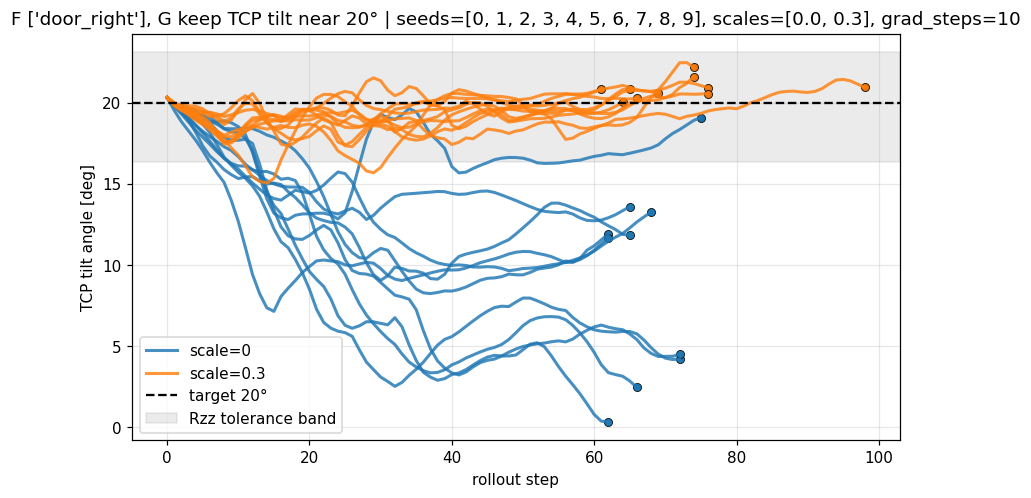

In [8]:
# Plot actual rollout tilt angle over time for unguided and Rzz-guided executions.
def plot_tilt_angle_over_time(rollouts, rzz_spec, title, save_path=None):
    scales = sorted({float(r["guidance_scale"]) for r in rollouts})
    cmap = plt.get_cmap("tab10")
    colors = {scale: cmap(i) for i, scale in enumerate(scales)}
    target_angle = float(rzz_spec.angle_deg)
    band_lo, band_hi = rzz_tolerance_band_deg_np(rzz_spec)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    used_labels = set()
    for rollout in rollouts:
        angles = np.asarray(
            rollout.get("tcp_tilt_angle_deg", rzz_to_tilt_angle_deg_np(rollout["tcp_rzz"], rzz_spec)),
            dtype=np.float32,
        )
        steps = np.arange(len(angles))
        scale = float(rollout["guidance_scale"])
        label = f"scale={scale:g}" if scale not in used_labels else None
        used_labels.add(scale)
        ax.plot(steps, angles, color=colors[scale], linewidth=2.0, alpha=0.82, label=label)
        ax.scatter([steps[-1]], [angles[-1]], color=colors[scale], s=28, edgecolor="black", linewidth=0.5)

    ax.axhline(target_angle, color="black", linestyle="--", linewidth=1.5, label=f"target {target_angle:g}°")
    ax.axhspan(band_lo, band_hi, color="black", alpha=0.08, label="Rzz tolerance band")
    ax.set_title(title)
    ax.set_xlabel("rollout step")
    ax.set_ylabel("TCP tilt angle [deg]")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_tilt_angle_over_time(
    rollouts, RZZ_SPEC,
    title=(
        f"F {GOAL_LABEL_NAMES}, G keep TCP tilt near {RZZ_SPEC.angle_deg:g}° | "
        f"seeds={SEEDS}, scales={GUIDANCE_SCALES}, grad_steps={GRADIENT_STEPS}"
    ),
    save_path=run_dir / "tilt_angle_over_time.png",
)


plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260522_035056/rollouts_xy.png


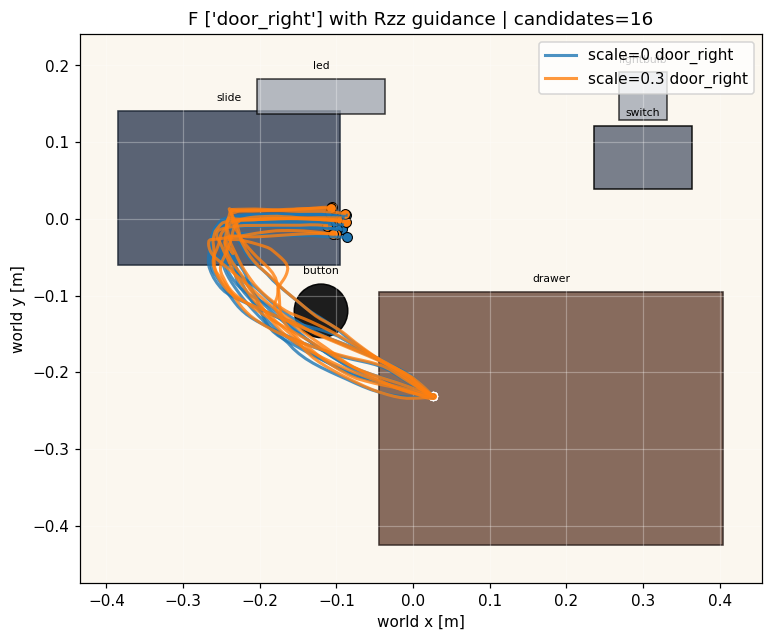

In [7]:
# Optional sanity plot: EEF XY paths, so we can see whether Rzz guidance preserves the switch-reaching behavior.
def plot_rollout_xy(rollouts, scene_snapshot, title, save_path=None):
    scales = sorted({float(r["guidance_scale"]) for r in rollouts})
    cmap = plt.get_cmap("tab10")
    colors = {scale: cmap(i) for i, scale in enumerate(scales)}
    all_xy = np.concatenate([np.asarray(r["eef_xy"], dtype=np.float32) for r in rollouts], axis=0)
    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax, scene_snapshot)
    used_labels = set()
    for rollout in rollouts:
        xy = np.asarray(rollout["eef_xy"], dtype=np.float32)
        scale = float(rollout["guidance_scale"])
        label = f"scale={scale:g} {rollout['behavior']}" if scale not in used_labels else None
        used_labels.add(scale)
        ax.plot(xy[:, 0], xy[:, 1], color=colors[scale], linewidth=2.0, alpha=0.8, label=label)
        ax.scatter(xy[0, 0], xy[0, 1], c=[colors[scale]], s=28, edgecolors="white", linewidths=0.7)
        ax.scatter(xy[-1, 0], xy[-1, 1], c=[colors[scale]], s=42, edgecolors="black", linewidths=0.7)
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, all_xy)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(title); ax.set_xlabel("world x [m]"); ax.set_ylabel("world y [m]"); ax.grid(alpha=0.3); ax.legend(loc="upper right")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_rollout_xy(
    rollouts, rollouts[0]["scene_snapshot"],
    title=f"F {GOAL_LABEL_NAMES} with Rzz guidance | candidates={N_CANDIDATES}",
    save_path=run_dir / "rollouts_xy.png",
)
